In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from final_project_d200.data import read_data
from final_project_d200.preprocessing import downsample
from final_project_d200.feature_engineering import add_past_returns, add_normalized_past_returns, add_past_mean_sq_returns
from final_project_d200.evaluation import (compute_mean_crps_arbitrary, optimize_gbt_constant_for_nll, calculate_normal_nll,
                                           compute_mean_crps_gaussian)
from final_project_d200.simulation import simulate_call_trades_normal
from final_project_d200.misc import get_gbt_sigmas

### Load Data

In [3]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 1: Distribution Conditional on Realized Vol
Standardized by realized volatility, what distribution best fits returns data? We will restrict our analysis to the training set.

In [4]:
df_train = df.query("split == 'train'")

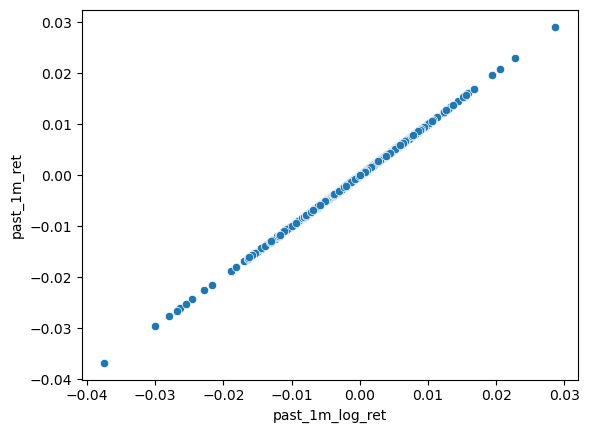

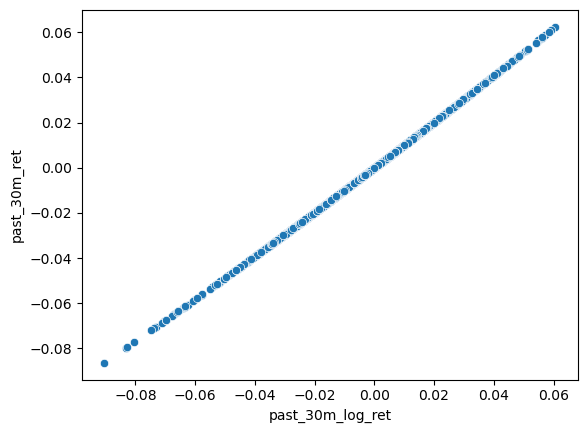

In [5]:
df_train = add_past_returns(df_train, [1, 30], log=False)
df_train = add_past_returns(df_train, [1, 30], log=True)

ax = sns.scatterplot(x=df_train["past_1m_log_ret"], y=df_train["past_1m_ret"])
plt.show()

ax = sns.scatterplot(x=df_train["past_30m_log_ret"], y=df_train["past_30m_ret"])
plt.show()

Okay - we will not use log returns for simplicity.

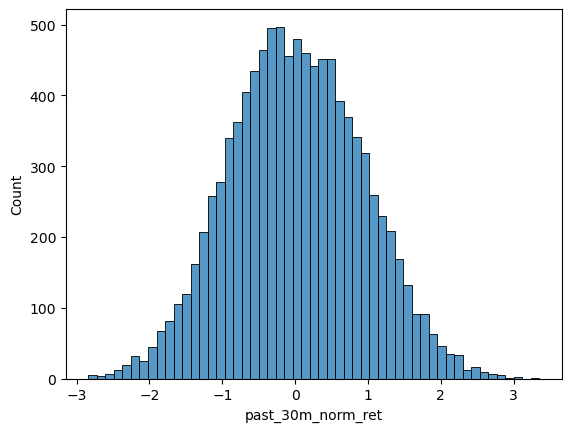

In [6]:
df_train = add_normalized_past_returns(df_train, [30])
ax = sns.histplot(df_train.sample(10000)["past_30m_norm_ret"])

Next step: compare normal vs. t vs. skewed t distribution. Fit parameters on train, then compare performance on val.

In [7]:
df_with_returns = downsample(add_normalized_past_returns(df, [30]).dropna(), set([0, 30]))
z_train = np.asarray(df_with_returns.query("split == 'train'")["past_30m_norm_ret"])
z_val = np.asarray(df_with_returns.query("split == 'val'")["past_30m_norm_ret"])
z_train = np.asarray(z_train)

# Fit distributions
_, scale_norm = stats.norm.fit(z_train, floc=0)

df_t, _, scale_t = stats.t.fit(z_train, floc=0)

a, b, _, scale_s = stats.jf_skew_t.fit(z_train, floc=0)

/opt/homebrew/Caskroom/miniconda/base/envs/final-project-d200/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:5715: RuntimeWarning: overflow encountered in scalar power
  c = 2 ** (a + b - 1) * sc.beta(a, b) * np.sqrt(a + b)
/opt/homebrew/Caskroom/miniconda/base/envs/final-project-d200/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:5715: RuntimeWarning: invalid value encountered in scalar multiply
  c = 2 ** (a + b - 1) * sc.beta(a, b) * np.sqrt(a + b)


In [8]:
logscore_default_norm = stats.norm.logpdf(
    z_val, loc=0, scale=1
).mean()

logscore_fitted_norm = stats.norm.logpdf(
    z_val, loc=0, scale=scale_norm
).mean()

logscore_t = stats.t.logpdf(
    z_val, df=df_t, loc=0, scale=scale_t
).mean()

logscore_s = stats.jf_skew_t.logpdf(
    z_val, a=a, b=b, loc=0, scale=scale_s
).mean()

print("Log scores\n")
print("Normal unit variance:", logscore_default_norm)
print("Normal fitted variance:", logscore_fitted_norm)
print("t:", logscore_t)
print("Skew-t:", logscore_s)

Log scores

Normal unit variance: -1.3810650767505672
Normal fitted variance: -1.3804724863183568
t: -1.3804724866004794
Skew-t: -1.3805018966429914


In [9]:
crps_default_norm = compute_mean_crps_arbitrary(stats.norm.cdf, z_val, -100, 100)
crps_fitted_norm = compute_mean_crps_arbitrary(stats.norm(scale=scale_norm).cdf, z_val, -100, 100)
crps_t = compute_mean_crps_arbitrary(stats.t(df=df_t, scale=scale_t).cdf, z_val, -100, 100)
crps_s = compute_mean_crps_arbitrary(stats.jf_skew_t(a=a, b=b, scale=scale_s).cdf, z_val, -100, 100)

print("CRPS\n")
print("Normal unit:", crps_default_norm)
print("Normal fitted:", crps_fitted_norm)
print("t:", crps_t)
print("Skew-t:", crps_s)

CRPS

Normal unit: 0.5466472785382782
Normal fitted: 0.5470640052023281
t: 0.5470640052732231
Skew-t: 0.5470321813931254


Okay! It looks like we can stick with normal for the two stage model, and potential try a multiplicative constant for scale. As a quick check, let's see what has better PnL if we allow them to trade against each other.

In [10]:
df = add_past_mean_sq_returns(df, [30])
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()
returns = df_val["past_30m_ret"].reset_index(drop=True)
sigmas_one = np.sqrt(df_val["past_30m_mean_sq_ret"].reset_index(drop=True) * 30)
sigmas_two = np.sqrt(df_val["past_30m_mean_sq_ret"].reset_index(drop=True) * 30) * scale_norm
pnls = simulate_call_trades_normal(0.005, returns, sigmas_one, sigmas_two)

<Axes: >

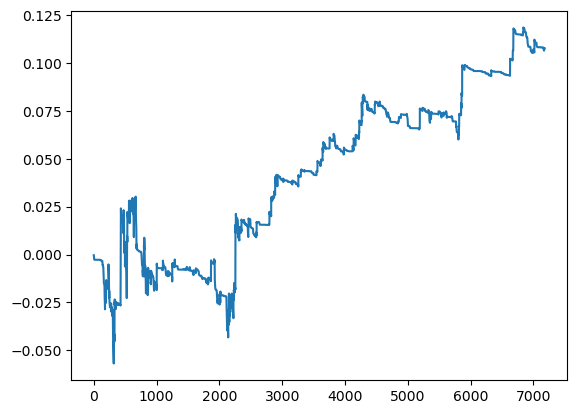

In [11]:
sns.lineplot(np.cumsum(pnls))

Looks about random!

### Part 2: Two-Stage Model
Now we evaluate our two stage model with GBT predictions and a normal distribution. We compare the raw prediction vs. the prediction up to some scale.

###

In [12]:
import numpy as np

df["future_30m_ret"] = df["past_30m_ret"].shift(-30)

df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna()
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()

y_train = df_train["future_30m_ret"].reset_index(drop=True)
sigma_train = get_gbt_sigmas(df_train)

y_val = df_val["future_30m_ret"].reset_index(drop=True)
sigma_val = get_gbt_sigmas(df_val)


nll_train_raw = calculate_normal_nll(y_train, sigma_train)
nll_val_raw = calculate_normal_nll(y_val, sigma_val)

c_hat = optimize_gbt_constant_for_nll(y_train, sigma_train)


sigma_train_const = c_hat * sigma_train
sigma_val_const = c_hat * sigma_val

nll_train_cal = calculate_normal_nll(y_train, sigma_train_const)
nll_val_cal = calculate_normal_nll(y_val, sigma_val_const)

print(f"Raw two stage NLL neg loglik: {nll_train_raw}")
print(f"Raw two stage val neg loglik: {nll_val_raw}\n")

print(f"Calibrated two stage NLL neg loglik: {nll_train_cal}")
print(f"Calibrated two stage val neg loglik: {nll_val_cal}")

Raw two stage NLL neg loglik: -4.3536277039424
Raw two stage val neg loglik: -4.508380701689935

Calibrated two stage NLL neg loglik: -4.356545926204101
Calibrated two stage val neg loglik: -4.511620758781937


In [13]:
crps_raw_val = compute_mean_crps_gaussian(y_val, sigma_val)
crps_const_val = compute_mean_crps_gaussian(y_val, sigma_val_const)

print("CRPS\n")
print("Raw two stage:", crps_raw_val)
print("Calibrated two stage:", crps_const_val)

CRPS

Raw two stage: 0.0016134541799030142
Calibrated two stage: 0.0016174550646100565


<Axes: >

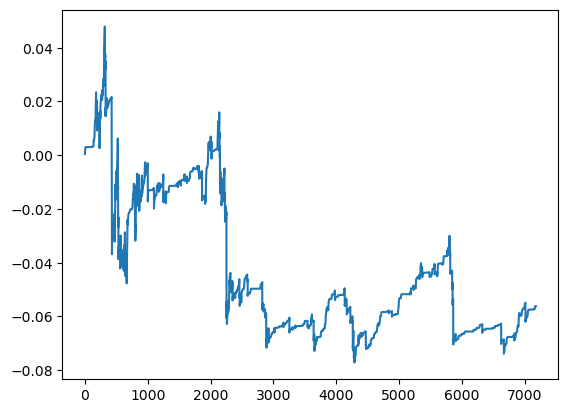

In [14]:
two_stage_pnls = simulate_call_trades_normal(0.005, y_val, sigma_val, sigma_val_const)
sns.lineplot(np.cumsum(two_stage_pnls))